# Feature Analysis And Model Selection Review

This notebook is for technical review of the dataset features and for selecting better candidate models. It focuses on:
- feature inventory and modeling readiness
- correlation and covariance structure
- feature-selection signals
- baseline comparison across multiple regression models

Use this after running `python main.py` so the transformed dataset and model metadata already exist.


## What This Notebook Answers

This notebook is designed to answer four concrete questions:

1. Which features have the strongest relationship with the target `price`?
2. Are there correlated or redundant features that may distort simple linear models?
3. Which features remain important after encoding and model fitting?
4. Which model family is the right next candidate after the current linear baseline?


In [ ]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "Notebook dependencies are missing. Install them with: python -m pip install -e '.[notebooks]'"
    ) from exc
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression


plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format


def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'main.py').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate the project root. Run this notebook from the local repository, or clone the repo into the current runtime.'
    )


REPO_ROOT = find_repo_root(Path.cwd())
TRANSFORMED_DATA_PATH = REPO_ROOT / 'artifacts' / 'processed' / 'usa_housing_transformed.csv'
TRANSFORM_META_PATH = REPO_ROOT / 'artifacts' / 'processed' / 'usa_housing_transformed.metadata.json'
MODEL_META_PATH = REPO_ROOT / 'artifacts' / 'models' / 'linear_regression_model.metadata.json'
MODEL_ARTIFACT_PATH = REPO_ROOT / 'artifacts' / 'models' / 'linear_regression_model.pkl'

required_paths = [
    TRANSFORMED_DATA_PATH,
    TRANSFORM_META_PATH,
    MODEL_META_PATH,
    MODEL_ARTIFACT_PATH,
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(f'Missing pipeline artifacts:\n{formatted}\nRun python main.py before opening this notebook.')

print(f'Repo root: {REPO_ROOT}')
print(f'Transformed data: {TRANSFORMED_DATA_PATH}')


Repo root: /Users/pranavchourasiya/pranav/house-price-ml
Transformed data: /Users/pranavchourasiya/pranav/house-price-ml/artifacts/processed/usa_housing_transformed.csv


In [28]:
transformed_df = pd.read_csv(TRANSFORMED_DATA_PATH)
transform_meta = json.loads(TRANSFORM_META_PATH.read_text(encoding='utf-8'))
model_meta = json.loads(MODEL_META_PATH.read_text(encoding='utf-8'))

with MODEL_ARTIFACT_PATH.open('rb') as file_obj:
    model_artifact = pickle.load(file_obj)

target_column = model_artifact['target_column']
numeric_feature_columns = list(model_artifact['numeric_feature_columns'])
categorical_feature_columns = list(model_artifact['categorical_feature_columns'])
all_feature_columns = numeric_feature_columns + categorical_feature_columns

for column in numeric_feature_columns + [target_column]:
    transformed_df[column] = pd.to_numeric(transformed_df[column], errors='coerce')

X = transformed_df[all_feature_columns].copy()
y = transformed_df[target_column].copy()

feature_inventory = pd.DataFrame(
    {
        'feature_name': all_feature_columns,
        'feature_type': ['numeric'] * len(numeric_feature_columns) + ['categorical'] * len(categorical_feature_columns),
        'missing_values': [int(X[column].isna().sum()) for column in all_feature_columns],
        'unique_values': [int(X[column].nunique(dropna=True)) for column in all_feature_columns],
    }
)
feature_inventory


,feature_name,feature_type,missing_values,unique_values
0,bedrooms,numeric,0,9
1,bathrooms,numeric,0,24
2,sqft_living,numeric,0,544
3,sqft_lot,numeric,0,2828
4,floors,numeric,0,6
5,waterfront,numeric,0,2
6,view,numeric,0,5
7,condition,numeric,0,5
8,sqft_above,numeric,0,490
9,sqft_basement,numeric,0,205


## Feature Inventory And Readiness


In [29]:
feature_readiness = pd.DataFrame(
    [
        {'Metric': 'Model-ready rows', 'Value': len(transformed_df)},
        {'Metric': 'Target column', 'Value': target_column},
        {'Metric': 'Numeric feature count', 'Value': len(numeric_feature_columns)},
        {'Metric': 'Categorical feature count', 'Value': len(categorical_feature_columns)},
        {'Metric': 'Derived columns', 'Value': ', '.join(transform_meta['derived_columns'])},
        {'Metric': 'Dropped source columns', 'Value': ', '.join(transform_meta['drop_columns'])},
    ]
)
feature_readiness


,Metric,Value
0,Model-ready rows,4091
1,Target column,price
2,Numeric feature count,15
3,Categorical feature count,2
4,Derived columns,"state, zipcode, sale_year, sale_month, sale_day"
5,Dropped source columns,"street, country, statezip, date"


In [30]:
numeric_summary = transformed_df[numeric_feature_columns + [target_column]].describe().T
numeric_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,mean,std,min,25%,50%,75%,max
bedrooms,3.3935,0.8991,0.0000,3.0000,3.0000,4.0000,8.0000
bathrooms,2.1566,0.7765,0.0000,1.7500,2.2500,2.5000,6.7500
sqft_living,"2,135.9313",949.3188,370.0000,"1,460.0000","1,980.0000","2,610.0000","10,040.0000"
sqft_lot,"14,676.6096","35,965.2658",638.0000,"5,000.0000","7,665.0000","10,952.5000","1,074,218.0000"
floors,1.5143,0.5352,1.0000,1.0000,1.5000,2.0000,3.5000
waterfront,0.0068,0.0825,0.0000,0.0000,0.0000,0.0000,1.0000
view,0.2400,0.7765,0.0000,0.0000,0.0000,0.0000,4.0000
condition,3.4498,0.6763,1.0000,3.0000,3.0000,4.0000,5.0000
sqft_above,"1,825.7895",852.8025,370.0000,"1,190.0000","1,600.0000","2,303.0000","7,680.0000"
sqft_basement,310.1418,461.9613,0.0000,0.0000,0.0000,600.0000,"4,820.0000"


## Correlation Analysis


In [31]:
corr_df = transformed_df[numeric_feature_columns + [target_column]].corr(numeric_only=True)
target_correlation = (
    corr_df[target_column]
    .drop(labels=[target_column])
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .rename('correlation_with_price')
    .to_frame()
)
target_correlation


,correlation_with_price
sqft_living,0.4347
sqft_above,0.3691
bathrooms,0.3327
view,0.2322
sqft_basement,0.2119
bedrooms,0.1993
waterfront,0.1464
floors,0.1445
sqft_lot,0.0469
sale_month,0.0406


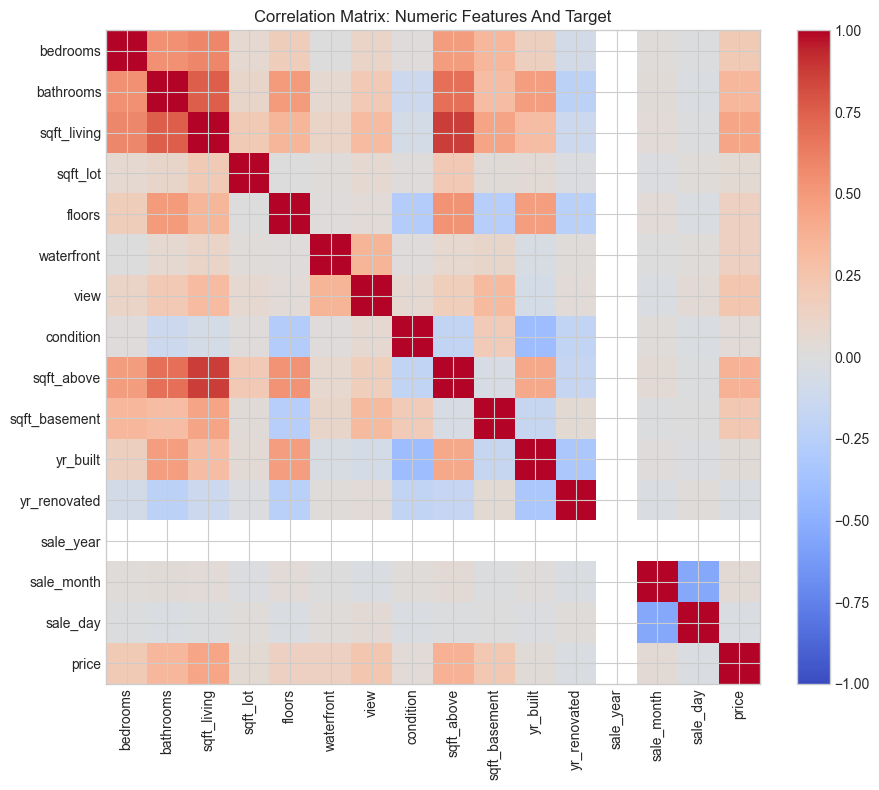

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticklabels(corr_df.index)
ax.set_title('Correlation Matrix: Numeric Features And Target')
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Covariance Analysis


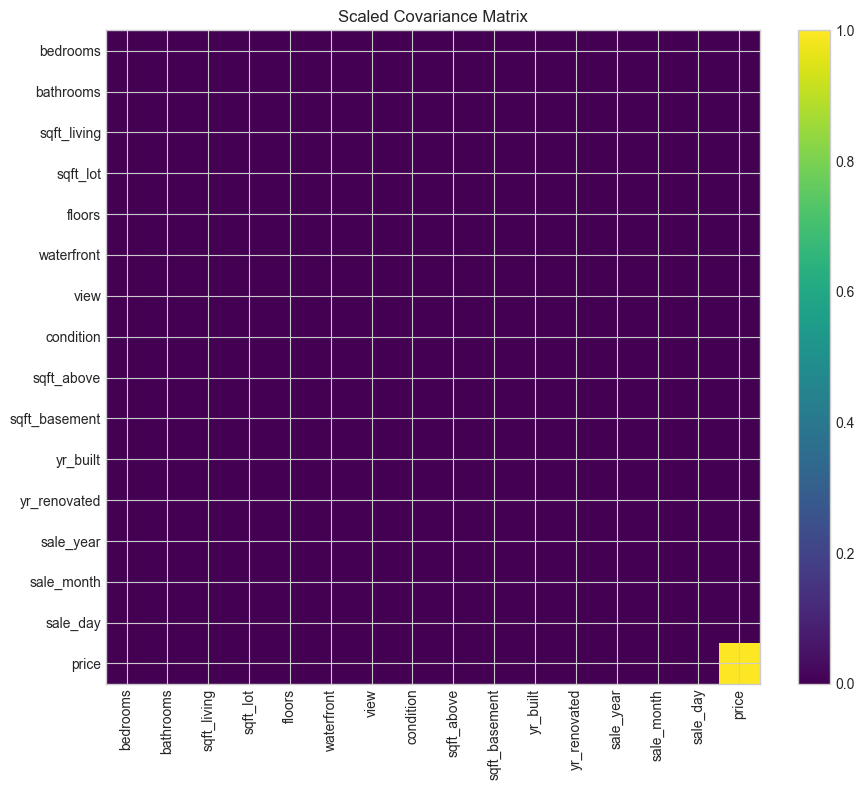

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,sale_year,sale_month,sale_day,price
bedrooms,0.8084,0.3800,504.7136,"2,207.4713",0.0852,-0.0002,0.0767,0.0085,367.3078,137.4058,4.0952,-62.4001,0.0000,0.0107,-0.0889,"104,671.9627"
bathrooms,0.3800,0.6030,557.2216,"2,762.3248",0.2040,0.0042,0.1227,-0.0651,453.3456,103.8760,10.9321,-170.3165,0.0000,0.0158,-0.1694,"150,895.2416"
sqft_living,504.7136,557.2216,"901,206.2571","6,724,765.0404",174.5901,9.0667,225.6810,-44.3711,"707,535.0083","193,671.2489","8,309.6750","-114,650.0145",0.0000,21.1814,-111.4457,"241,019,508.5653"
sqft_lot,"2,207.4713","2,762.3248","6,724,765.0404","1,293,500,343.5882",-11.5196,57.7457,"1,944.2607",305.4597,"6,316,850.2687","407,914.7717","48,815.0675","-649,401.1545",0.0000,-485.3885,"5,078.7276","985,830,214.1686"
floors,0.0852,0.2040,174.5901,-11.5196,0.2864,0.0006,0.0131,-0.0991,239.2110,-64.6209,7.4943,-124.0424,0.0000,0.0129,-0.1314,"45,147.1532"
waterfront,-0.0002,0.0042,9.0667,57.7457,0.0006,0.0068,0.0221,0.0006,5.2181,3.8487,-0.1022,1.7922,0.0000,-0.0002,0.0114,"7,052.2637"
view,0.0767,0.1227,225.6810,"1,944.2607",0.0131,0.0221,0.6030,0.0336,110.8315,114.8496,-1.6217,24.4602,0.0000,-0.0131,0.2621,"105,281.0787"
condition,0.0085,-0.0651,-44.3711,305.4597,-0.0991,0.0006,0.0336,0.4573,-104.8911,60.5201,-8.0617,-122.7892,0.0000,0.0095,-0.1644,"13,637.2442"
sqft_above,367.3078,453.3456,"707,535.0083","6,316,850.2687",239.2110,5.2181,110.8315,-104.8911,"727,272.0444","-19,737.0362","10,544.8328","-137,298.6811",0.0000,24.2294,-86.5844,"183,846,911.6153"
sqft_basement,137.4058,103.8760,"193,671.2489","407,914.7717",-64.6209,3.8487,114.8496,60.5201,"-19,737.0362","213,408.2850","-2,235.1578","22,648.6666",0.0000,-3.0480,-24.8613,"57,172,596.9500"


In [33]:
covariance_df = transformed_df[numeric_feature_columns + [target_column]].cov(numeric_only=True)
scaled_covariance = covariance_df / covariance_df.abs().max().max()

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(scaled_covariance.values, cmap='viridis')
ax.set_xticks(range(len(scaled_covariance.columns)))
ax.set_yticks(range(len(scaled_covariance.index)))
ax.set_xticklabels(scaled_covariance.columns, rotation=90)
ax.set_yticklabels(scaled_covariance.index)
ax.set_title('Scaled Covariance Matrix')
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

covariance_df


## Feature Selection Signals


In [34]:
encoded_X = pd.get_dummies(X, columns=categorical_feature_columns, drop_first=False)

f_selector = SelectKBest(score_func=f_regression, k=min(15, encoded_X.shape[1]))
f_selector.fit(encoded_X, y)
f_scores = pd.DataFrame(
    {
        'feature': encoded_X.columns,
        'f_regression_score': f_selector.scores_,
    }
).sort_values('f_regression_score', ascending=False)

mi_selector = SelectKBest(score_func=mutual_info_regression, k=min(15, encoded_X.shape[1]))
mi_selector.fit(encoded_X, y)
mi_scores = pd.DataFrame(
    {
        'feature': encoded_X.columns,
        'mutual_information_score': mi_selector.scores_,
    }
).sort_values('mutual_information_score', ascending=False)

feature_selection_summary = (
    f_scores.merge(mi_scores, on='feature', how='outer')
    .fillna(0)
    .assign(
        average_rank=lambda df: (
            df['f_regression_score'].rank(ascending=False, method='min')
            + df['mutual_information_score'].rank(ascending=False, method='min')
        ) / 2
    )
    .sort_values(['average_rank', 'f_regression_score'], ascending=[True, False])
)

feature_selection_summary.head(20)


,feature,f_regression_score,mutual_information_score,average_rank
52,sqft_living,952.8795,0.3331,1.0000
50,sqft_above,645.0854,0.2481,2.0000
0,bathrooms,509.1103,0.1871,3.0000
51,sqft_basement,192.2658,0.0706,5.5000
1,bedrooms,169.2085,0.0753,5.5000
55,view,232.9294,0.0488,6.5000
46,floors,87.1393,0.0576,8.5000
5,city_Bellevue,82.6801,0.0269,11.0000
53,sqft_lot,9.0277,0.0809,11.0000
3,city_Auburn,33.7910,0.0207,13.0000


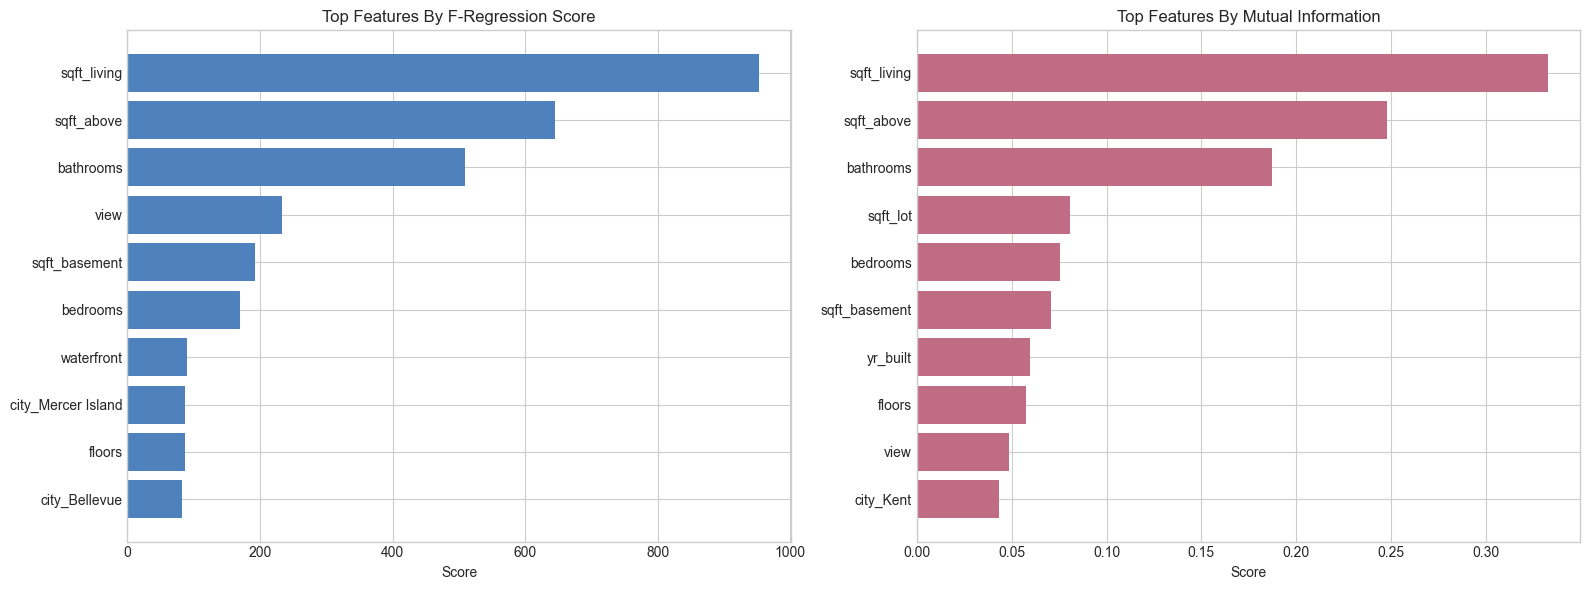

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

f_top = f_scores.head(10).sort_values('f_regression_score')
axes[0].barh(f_top['feature'], f_top['f_regression_score'], color='#4f81bd')
axes[0].set_title('Top Features By F-Regression Score')
axes[0].set_xlabel('Score')

mi_top = mi_scores.head(10).sort_values('mutual_information_score')
axes[1].barh(mi_top['feature'], mi_top['mutual_information_score'], color='#c06c84')
axes[1].set_title('Top Features By Mutual Information')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()


In [36]:
random_forest_for_importance = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
random_forest_for_importance.fit(encoded_X, y)

rf_importance = pd.DataFrame(
    {
        'feature': encoded_X.columns,
        'random_forest_importance': random_forest_for_importance.feature_importances_,
    }
).sort_values('random_forest_importance', ascending=False)

rf_importance.head(20)


,feature,random_forest_importance
2,sqft_living,0.3815
32,city_Kent,0.1097
10,yr_built,0.0871
8,sqft_above,0.0822
3,sqft_lot,0.0746
14,sale_day,0.0451
9,sqft_basement,0.0414
1,bathrooms,0.0278
11,yr_renovated,0.0217
49,city_Seattle,0.0187


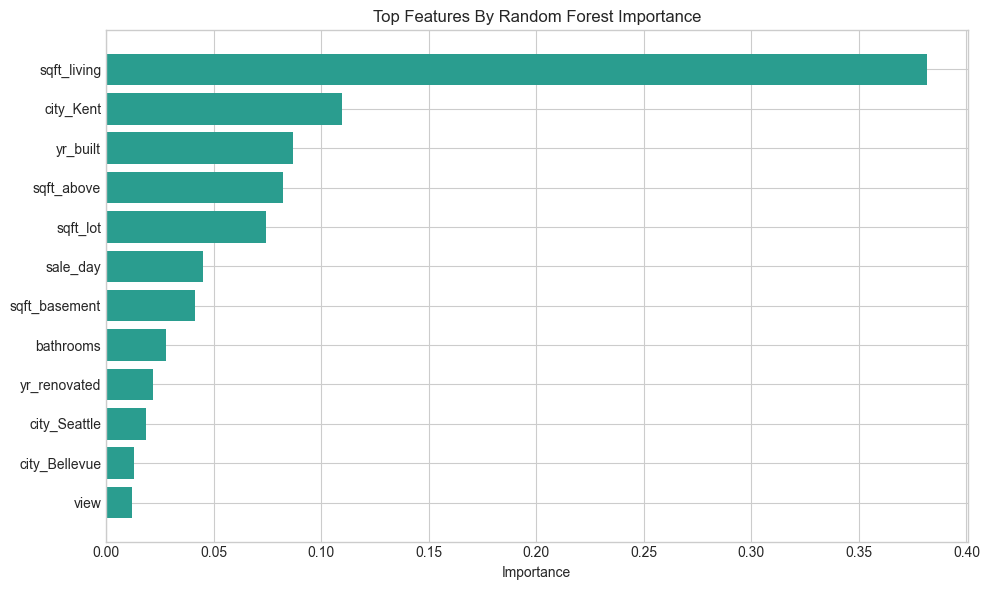

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
rf_top = rf_importance.head(12).sort_values('random_forest_importance')
ax.barh(rf_top['feature'], rf_top['random_forest_importance'], color='#2a9d8f')
ax.set_title('Top Features By Random Forest Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## Model Selection Analysis


In [38]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def build_preprocessor(scale_numeric: bool, dense_output: bool = False) -> ColumnTransformer:
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=not dense_output,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_feature_columns),
            ("categorical", categorical_pipeline, categorical_feature_columns),
        ],
        sparse_threshold=0 if dense_output else 0.3,
    )


candidate_models = {
    "linear_regression": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=True, dense_output=False)),
            ("model", LinearRegression()),
        ]
    ),
    "ridge": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=True, dense_output=False)),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=False, dense_output=False)),
            ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
        ]
    ),
    "hist_gradient_boosting": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=False, dense_output=True)),
            ("model", HistGradientBoostingRegressor(random_state=42)),
        ]
    ),
}

scoring = {
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(rmse, greater_is_better=False),
    "r2": make_scorer(r2_score),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_rows = []
for model_name, pipeline in candidate_models.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    model_rows.append(
        {
            "model_name": model_name,
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_mae_std": scores["test_mae"].std(),
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
        }
    )

model_comparison_df = pd.DataFrame(model_rows).sort_values(
    ["cv_rmse_mean", "cv_mae_mean"]
)

model_comparison_df

,model_name,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
1,ridge,"139,188.3867","21,046.1034","376,458.0141","335,407.0486",0.5564,0.2563
0,linear_regression,"139,335.9423","21,072.1839","377,005.8184","335,195.5068",0.5548,0.2558
3,hist_gradient_boosting,"150,294.1570","15,714.4627","413,647.5520","317,766.6939",0.4284,0.2058
2,random_forest,"136,920.8870","20,856.2483","418,222.3705","315,234.8927",0.4119,0.1882


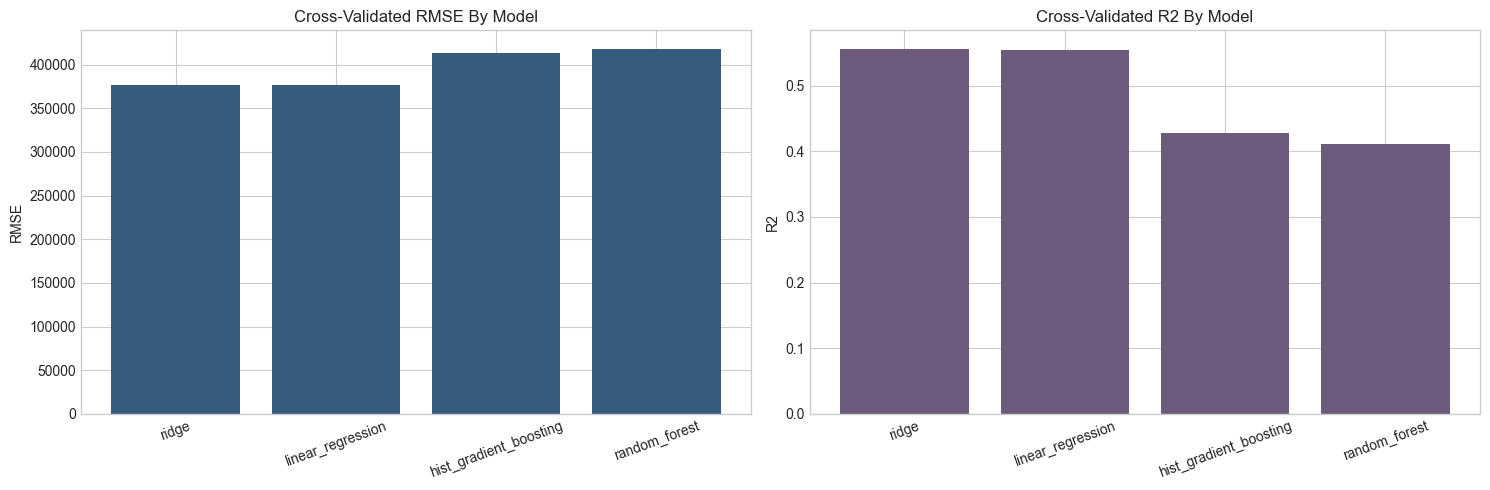

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison_view = model_comparison_df.copy()

axes[0].bar(comparison_view['model_name'], comparison_view['cv_rmse_mean'], color='#355c7d')
axes[0].set_title('Cross-Validated RMSE By Model')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comparison_view['model_name'], comparison_view['cv_r2_mean'], color='#6c5b7b')
axes[1].set_title('Cross-Validated R2 By Model')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Model Choice Guidance


In [ ]:
best_model = model_comparison_df.iloc[0]
linear_metrics_path = REPO_ROOT / 'artifacts' / 'evaluation' / 'linear_regression_metrics.json'
random_forest_metrics_path = REPO_ROOT / 'artifacts' / 'evaluation' / 'random_forest_metrics.json'

holdout_comparison_df = pd.DataFrame(
    [
        json.loads(linear_metrics_path.read_text(encoding='utf-8')),
        json.loads(random_forest_metrics_path.read_text(encoding='utf-8')),
    ]
)[['model_name', 'mae', 'rmse', 'r2', 'evaluated_row_count']].sort_values('mae')

model_choice_summary = pd.DataFrame(
    [
        {'Decision area': 'Current default baseline', 'Recommendation': 'linear_regression'},
        {'Decision area': 'Best CV candidate in this notebook', 'Recommendation': best_model['model_name']},
        {'Decision area': 'Hold-out winner by MAE', 'Recommendation': holdout_comparison_df.iloc[0]['model_name']},
        {'Decision area': 'Hold-out winner by RMSE and R2', 'Recommendation': 'linear_regression'},
        {'Decision area': 'Decision after challenger run', 'Recommendation': 'Keep linear_regression as the default. random_forest reduced MAE slightly, but it degraded RMSE and R2 on the fixed hold-out split.'},
        {'Decision area': 'Immediate next experiment', 'Recommendation': 'Inspect residuals by city and price band, then test another challenger such as hist_gradient_boosting before changing the production default.'},
    ]
)

display(holdout_comparison_df)
model_choice_summary


## Recommended Technical Conclusions

Expected interpretation of this notebook:
- `sqft_living`, `sqft_above`, `bathrooms`, `view`, and location-derived features are likely to dominate price signal.
- Several physical-size variables are correlated, which is acceptable for tree models but can destabilize simple linear coefficients.
- Feature selection should not rely on one method alone. Correlation, mutual information, and model-based importance each capture different parts of the signal.
- Cross-validation is useful for shortlisting challengers, but the production default should still be decided on the fixed hold-out comparison.
- In the current challenger run, `random_forest` improved MAE slightly versus `linear_regression`, but it was worse on RMSE and R2, so it is not a clear replacement.

Recommended next actions:
1. Keep the current linear regression as the reproducible baseline.
2. Preserve the `random_forest` artifacts as challenger evidence, but do not promote it to the default model.
3. Add residual analysis by city and price band to understand where each model misses.
4. Test another challenger such as `hist_gradient_boosting` before changing the production default.
